In [2]:
from pathlib import Path
from PIL import Image
import sys
sys.path.append("..")
from utils.common import load_config

cfg = load_config()
root = cfg["paths"]["data_root"]
categories = cfg["categories"]

In [3]:
rows = []
for cat in categories:
    n_train = len(list((root/cat/"train"/"good").glob("*.png")))
    test_dir = root/cat/"test"
    defect_types = [d.name for d in test_dir.iterdir() if d.is_dir() and d.name != "good"]
    n_test_good = len(list((test_dir/"good").glob("*.png")))
    n_test_defect = sum(len(list((test_dir/d).glob("*.png"))) for d in defect_types)
    rows.append((cat, n_train, n_test_good, n_test_defect, defect_types))

for r in rows:
    print(r[0], "train:", r[1], "test_good:", r[2], "test_defect:", r[3], "types:", r[4])

bottle train: 209 test_good: 20 test_defect: 63 types: ['broken_large', 'broken_small', 'contamination']
cable train: 224 test_good: 58 test_defect: 92 types: ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'missing_cable', 'missing_wire', 'poke_insulation']
capsule train: 219 test_good: 23 test_defect: 109 types: ['crack', 'faulty_imprint', 'poke', 'scratch', 'squeeze']
carpet train: 280 test_good: 28 test_defect: 89 types: ['color', 'cut', 'hole', 'metal_contamination', 'thread']
grid train: 264 test_good: 21 test_defect: 57 types: ['bent', 'broken', 'glue', 'metal_contamination', 'thread']
hazelnut train: 391 test_good: 40 test_defect: 70 types: ['crack', 'cut', 'hole', 'print']
leather train: 245 test_good: 32 test_defect: 92 types: ['color', 'cut', 'fold', 'glue', 'poke']
metal_nut train: 220 test_good: 22 test_defect: 93 types: ['bent', 'color', 'flip', 'scratch']
pill train: 267 test_good: 26 test_defect: 141 types: ['color', 'combined', '

In [4]:
for cat in categories:
    p = next((root/cat/"train"/"good").glob("*.png"))
    img = Image.open(p)
    print(cat, img.mode, img.size)

bottle RGB (900, 900)
cable RGB (1024, 1024)
capsule RGB (1000, 1000)
carpet RGB (1024, 1024)
grid L (1024, 1024)
hazelnut RGB (1024, 1024)
leather RGB (1024, 1024)
metal_nut RGB (700, 700)
pill RGB (800, 800)
screw L (1024, 1024)
tile RGB (840, 840)
toothbrush RGB (1024, 1024)
transistor RGB (1024, 1024)
wood RGB (1024, 1024)
zipper L (1024, 1024)


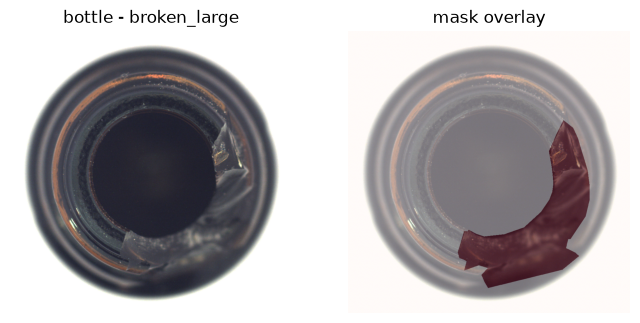

In [5]:
import matplotlib.pyplot as plt
import numpy as np

cat = "bottle"
test_dir = root/cat/"test"
defect = [d for d in test_dir.iterdir() if d.is_dir() and d.name != "good"][0].name
img_path = sorted((test_dir/defect).glob("*.png"))[0]
mask_path = root/cat/"ground_truth"/defect/f"{img_path.stem}_mask.png"

img = Image.open(img_path).convert("RGB")
mask = Image.open(mask_path)

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].imshow(img); ax[0].set_title(f"{cat} - {defect}")
ax[1].imshow(img); ax[1].imshow(mask, alpha=0.4, cmap="Reds"); ax[1].set_title("mask overlay")
for a in ax: a.axis("off")
plt.show()

## Summary

- Grayscale: Grid,Screw,Zipper
- Defect type:
    - `Bottle` : broken_large, broken_small, contamination
    - `Cable` : bent_wire, cable_swap, combined, cut_inner_insulation, cut_outer_insulation, missing_cable, missing_wire, poke_insulation
    - `Capsule` : crack, faulty_imprint, poke, scratch, squeeze'
    - `Carpet` : color, cut, hole, metal_contamination, thread
    - `Grid` : bent, broken, glue, metal_contamination, thread
    - `Hazelnut` : crack, cut, hole, print
    - `Leather` : color, cut, fold, glue, poke
    - `Metal_nut` : bent, color, flip, scratch
    - `Pill` : color, combined, contamination, crack, faulty_imprint, pill_type, scratch
    - `Screw` : manipulated_front, scratch_head, scratch_neck, thread_side, thread_top
    - `Tile` : crack, glue_strip, gray_stroke, oil, rough
    - `Toothbrush` : defective
    - `Transistor` : bent_lead, cut_lead, damaged_case, misplaced
    - `Wood` : color, combined, hole, liquid, scratch
    - `Zipper` : broken_teeth, combined, fabric_border, fabric_interior, rough, split_teeth, squeezed_teeth
